In [21]:
import os, re
import time

import pickle 
import numpy as np
from hybrid_estimator.batchCVP import batchCVPP_cost
out_path = "lwe_instances/reduced_lattices/"

# with open( "./agr.pkl", "rb" ) as file:
#     otmp = pickle.load( file )

# o = []
# for oo in otmp:
#     if oo['kyb'][0] in [140,150,160]:
#         o.append( oo )

sec_type = "ternary"
sec_param = float(1/12)
q = 3329
dist=sec_type
dist_param=sec_param

with open("./lwe_instances/reduced_lattices/exp_[170, 180, 190, 200, 210]_3329_ternary_0.0833.pkl", "rb") as file:
    out = pickle.load( file )
    
lwe_inst = [ #do we need lats_per_dim and inst_per_lat?
    {"n": 170, "q": 3329, "dist": 'ternary', "dist_param": sec_param},
    {"n": 180, "q": 3329, "dist": 'ternary', "dist_param": sec_param},
    {"n": 190, "q": 3329, "dist": 'ternary', "dist_param": sec_param},
    {"n": 200, "q": 3329, "dist": 'ternary', "dist_param": sec_param},
    {"n": 210, "q": 3329, "dist": 'ternary', "dist_param": sec_param},
]

hparams = { #n_guess_coord's, n_slicer_coord from preprocessing.py
    # 140: (8,46),
    # 150: (8,46),
    160: (6,45),
    170: (8,49),
    180: (8,53),
    190: (8,60),
    200: (8,67),
    210: (8,77)
}

outpre = []
corresponding_blocksizes = {160:42, 170:42, 180:55, 190:55, 200:65, 210:65} #betapre's from attack_on_kyber
for n in corresponding_blocksizes.keys():
    betapre = corresponding_blocksizes[n]
    for seed in range(10):
        filename = f"report_pre_{n}_{q}_{sec_type}_{dist_param:0.4f}_{seed}_{betapre}.pkl"
        with open( out_path + filename, "rb" ) as file:
            outpre.append( pickle.load( file ) )

print(f"len(outp): {len(out)}")
print(f"len(outpre): {len(outpre)}")

maxbeta = 0
for oo in out:
    if oo["beta"] > maxbeta:
        maxbeta = oo["beta"]

print( maxbeta )

len(outp): 420
len(outpre): 60
86


{170: 51.7700000000000, 180: 56.4800000000000, 190: 62.2400000000000, 200: 69.6000000000000, 210: 78.7300000000000}
{170: 1.8267731112538304, 180: 1.571496102445055, 190: 2.867472754883645, 200: 2.922327839240491, 210: 3.466568908878057}


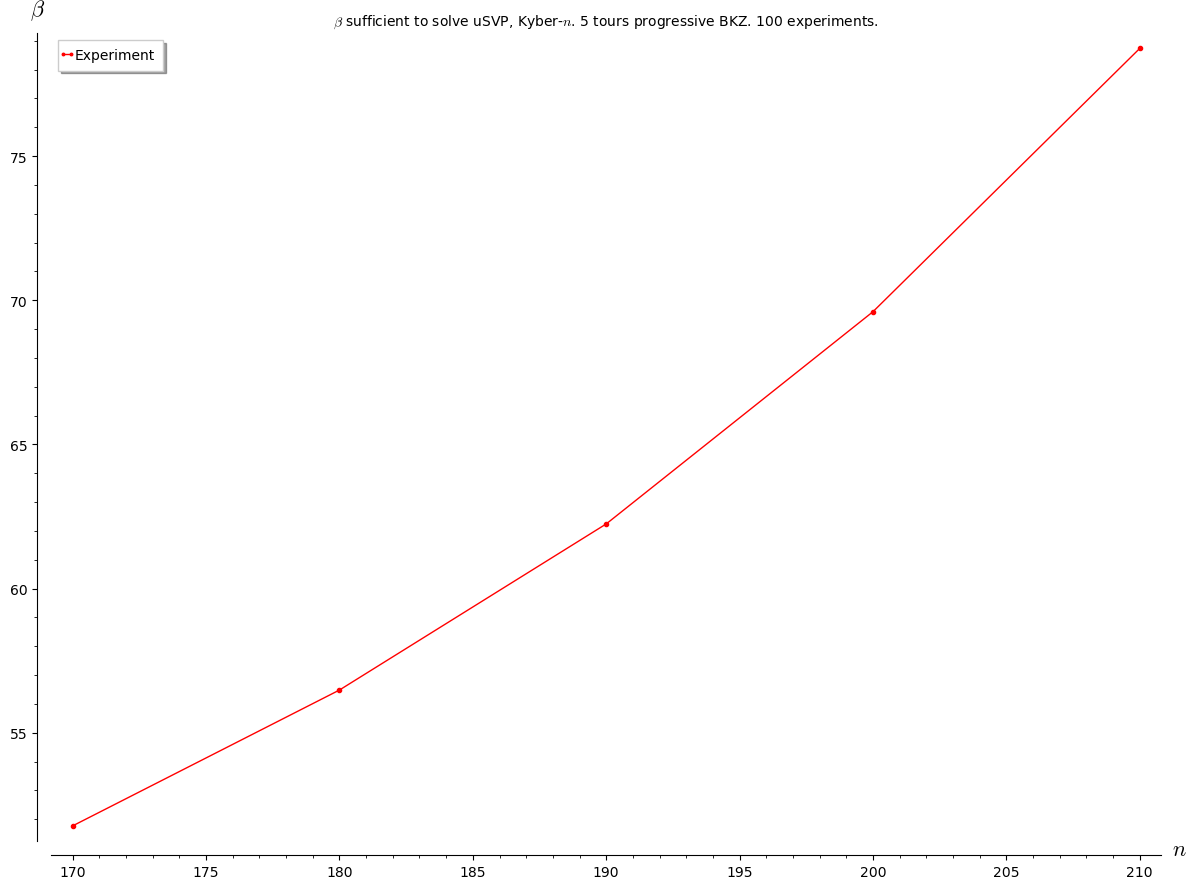

In [22]:
l = {}
ddl = {}

#extracting the mean blocksize
for oo in out:
    if not oo["kyb"][0] in l.keys():
        l[oo["kyb"][0]] = [ oo["beta"], 1 ]
        ddl[oo["kyb"][0]] = [ oo["beta"] ]
    else:
        l[oo["kyb"][0]][0] += oo["beta"]
        l[oo["kyb"][0]][1] += 1
        ddl[oo["kyb"][0]].append( oo["beta"] )

for key in l.keys():
    l[key] = l[key][0]/l[key][1].n()
    ddl[key] = np.std(ddl[key])

l_primal = l
print( l_primal )
print( ddl )

P = list_plot(l, plotjoined=True, marker='.',color="red", legend_label="Experiment")

P.show( axes_labels=['$n$', '$\\beta$'], title=f'$\\beta$ sufficient to solve uSVP, Kyber-$n$. 5 tours progressive BKZ. 100 experiments.', figsize=12 )

sec_param: 0.08333333333333333
report_prehyb_170_3329_ternary_0.0833_0_8_50_51_49.pkl
report_prehyb_170_3329_ternary_0.0833_1_8_50_51_49.pkl
report_prehyb_180_3329_ternary_0.0833_0_8_54_55_53.pkl
report_prehyb_180_3329_ternary_0.0833_1_8_54_55_53.pkl
report_prehyb_180_3329_ternary_0.0833_2_8_54_55_53.pkl
report_prehyb_180_3329_ternary_0.0833_3_8_54_55_53.pkl
report_prehyb_180_3329_ternary_0.0833_4_8_54_55_53.pkl
report_prehyb_180_3329_ternary_0.0833_5_8_54_55_53.pkl
report_prehyb_180_3329_ternary_0.0833_6_8_54_55_53.pkl
report_prehyb_180_3329_ternary_0.0833_7_8_54_55_53.pkl
report_prehyb_180_3329_ternary_0.0833_8_8_54_55_53.pkl
report_prehyb_180_3329_ternary_0.0833_9_8_54_55_53.pkl
report_prehyb_190_3329_ternary_0.0833_0_8_61_62_60.pkl
report_prehyb_190_3329_ternary_0.0833_1_8_61_62_60.pkl
report_prehyb_190_3329_ternary_0.0833_2_8_61_62_60.pkl
report_prehyb_190_3329_ternary_0.0833_3_8_61_62_60.pkl
report_prehyb_190_3329_ternary_0.0833_4_8_61_62_60.pkl
report_prehyb_190_3329_ternary_0.0

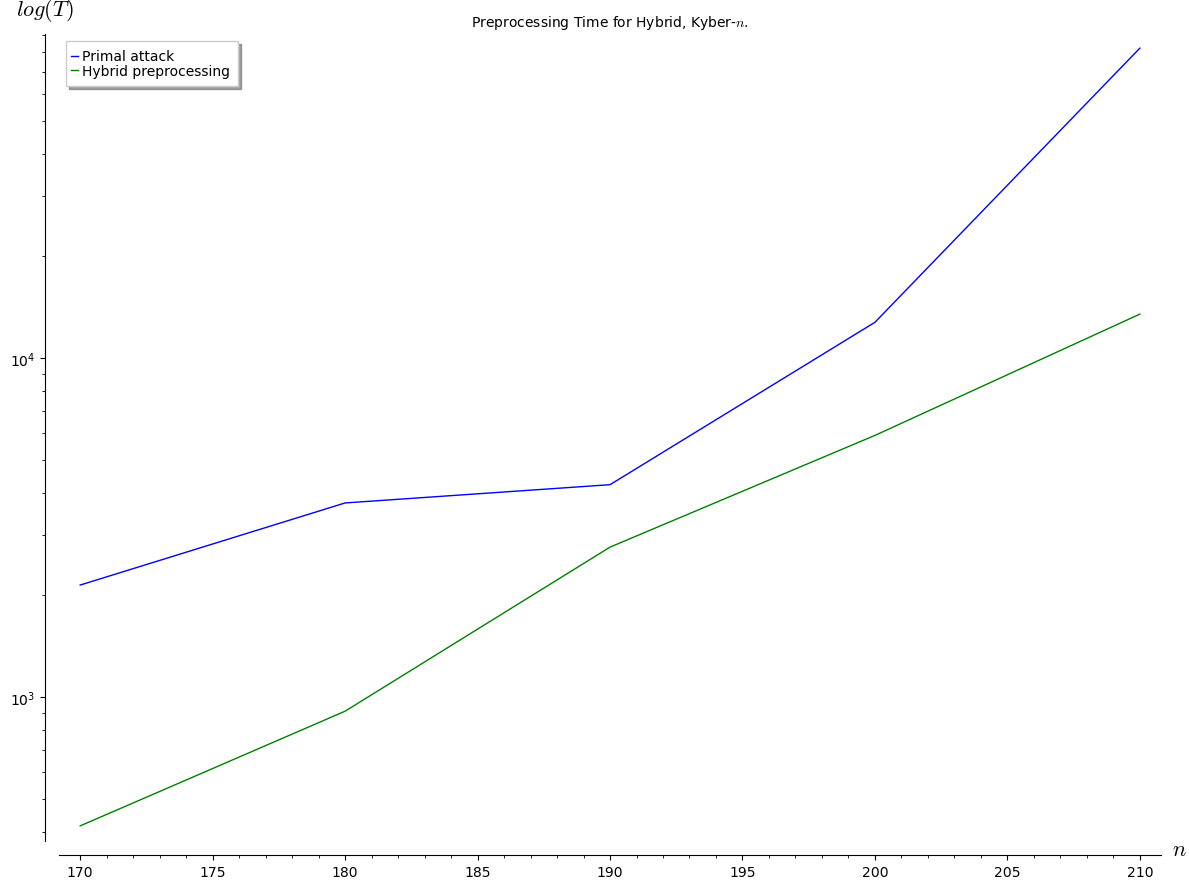

In [23]:
from sample import Distribution, ternaryDist, centeredBinomial

from hybrid_estimator.batchCVP import batchCVPP_cost


if sec_type=="binomial":
    distrib = centeredBinomial(sec_param)
elif sec_type=="ternary":
     print(f"sec_param: {sec_param}")
     distrib = ternaryDist(sec_param)

# extracting the primal preprocessing timing
r = {}
for oo in outpre:
    n, seed = oo['kyb'][0], oo['kyb'][4][0]
    if not n in r.keys(): 
        r[n] = [ oo["time"], 1 ]
    else:
        r[n][0] += oo["time"]
        r[n][1] += 1


#averaging the timing
for key in r.keys():
    r[key] = r[key][0]/r[key][1].n()

# extracting the primal attack timing
l = {}
for oo in out:
    if not oo["kyb"][0] in l.keys():
        l[oo["kyb"][0]] = [ oo["time"], 1 ]
    else:
        l[oo["kyb"][0]][0] += oo["time"]
        l[oo["kyb"][0]][1] += 1

# averaging it
for key in l.keys():
    l[key] = l[key][0]/l[key][1].n() + r[key]
    ddl[key] = np.std(ddl[key])

primal_timings = deepcopy(l)
# - - - 
P = list_plot_semilogy(l, plotjoined=True, legend_label="Primal attack")

data = []
path = "./lwe_instances/reduced_lattices/"
# regex = re.compile(r'^report_prehyb_(\d+)_')
pattern = re.compile(r'''
    ^report_prehyb_             
    (?P<n>\d+)_                 
    (?P<q>\d+)_                 
    (?P<dist>[^_]+)_            
    (?P<dist_param>[+-]?\d+\.\d{4})_  
    (?P<seed>\d+)_              
    (?P<kappa>\d+)_             
    (?P<sieve_dim_min>\d+)_     
    (?P<sieve_dim_max>\d+)_     
    (?P<beta_bkz>\d+)           
    \.pkl$
''', re.VERBOSE)
regex = re.compile(pattern)

for path, directories, files in os.walk(path):
    for candidate in files:
        match = regex.match(candidate)
        if match and sec_type in candidate and f"{sec_param:0.4f}" in candidate:
            gd = match.groupdict()
            n             = int(gd['n'])
            q             = int(gd['q'])
            dist          = gd['dist']
            dist_param    = float(gd['dist_param'])
            seed          = int(gd['seed'])
            kappa         = int(gd['kappa'])
            sieve_dim_min = int(gd['sieve_dim_min'])
            sieve_dim_max = int(gd['sieve_dim_max'])
            beta_bkz      = int(gd['beta_bkz'])
            # print(f"n: {n} sec: {sec_type} {kappa}")
            print(f"{candidate}")
            try:
                # try:
                #     print(ncur)
                # except KeyError:
                #     continue
                try:
                    # print(
                    #     n in [tmp["n"] for tmp in lwe_inst] ,
                    #     kappa==hparams[n][0] ,
                    #     beta_bkz == hparams[n][1],
                    #     sec_type in candidate ,
                    #     f"{sec_param:0.4f}" in candidate ,
                    #     f"_{hparams[n][0]}_" in candidate
                    # )
                    if ( #ncur in [tmp["n"] for tmp in lwe_inst] and
                        n in [tmp["n"] for tmp in lwe_inst] and
                        kappa == hparams[n][0] and
                        beta_bkz == hparams[n][1] and
                        sec_type in candidate and
                        f"{sec_param:0.4f}" in candidate and
                        f"_{hparams[n][0]}_" in candidate
                    ):
                        with open( path+candidate, "rb" ) as file:
                            data.append( pickle.load(file) )
                except KeyError as err:
                    print( err )
                    pass
            except ValueError as expt:
                print(expt)
                pass

processed_data = {}
for D in data: #loading from the text output
    n, q, dist, sec_param, seed = D["params"]
    if dist != sec_type:
        print(f"wrong dist: {dist}")
        continue
    sieve_dim_max = D["sieve_dim_max"]
    sieve_dim_min = D["sieve_dim_min"]
    kappa = D["kappa"]
    if kappa != hparams[n][0]: #or sieve_dim_min != hparams[n][1]:
        continue
    
    bkz_runtime = D["bkz_runtime"]
    bdgl_runtime = D["bdgl_runtime"]

    nsampl = ceil( 2 ** ( distrib.entropy * kappa ) )

    for i in range(len(bdgl_runtime)):
        sievedim = sieve_dim_max-i
        latdim = n - kappa
        if not (n,kappa,sievedim,latdim) in processed_data.keys():
            processed_data[(n,kappa,sievedim,latdim)] = {"bkz_runtime": [], "bdgl_runtime": [], "succrate": 0.}
        processed_data[(n,kappa,sievedim,latdim)]["bkz_runtime"].append( bkz_runtime )
        processed_data[(n,kappa,sievedim,latdim)]["bdgl_runtime"].append( bdgl_runtime )

aggrigated_data = {}
for (n,k,sievedim,latdim) in processed_data.keys():
    D = processed_data[(n,k,sievedim,latdim)]
    bkz_runtime = np.mean( D["bkz_runtime"] )
    bdgl_runtime = np.mean( D["bdgl_runtime"], axis=int(0) )
    
    aggrigated_data[ (n,k,sievedim) ] =  bkz_runtime + np.zeros(len(bdgl_runtime))



l0, l1 = {}, {}

for (n,k,sievedim) in aggrigated_data.keys():
    l0[n] = aggrigated_data[(n,k,sievedim)][-1]
    l1[n] = aggrigated_data[(n,k,sievedim)][0]

print(l)
print(l1)

preprocess_hyb_time = deepcopy(l0)

P += list_plot_semilogy(l0, plotjoined=True, base=10, axes_labels=["$n$", "$log(T)$"], color="green", legend_label="Hybrid preprocessing")
P.show( title=f'Preprocessing Time for Hybrid, Kyber-$n$.', figsize=12 )

In [24]:
l0, l1

({170: 416.8638902582073,
  180: 908.5000537410999,
  190: 2769.3560955776525,
  200: 5915.326080965732,
  210: 13483.810571766795},
 {170: 416.8638902582073,
  180: 908.5000537410999,
  190: 2769.3560955776525,
  200: 5915.326080965732,
  210: 13483.810571766795})

aaaa: exp_[140, 150, 160, 170]_3329_binomial_3.pkl | None
aaaa: exp_[160, 170, 180, 190, 200]_3329_ternary_0.1667.pkl | None
aaaa: exp_[170, 180, 190, 200, 210]_3329_ternary_0.0833.pkl | None
aaaa: report_prehyb_140_3329_binomial_3.0000_0_1_62_63_61.pkl | None
aaaa: report_prehyb_140_3329_binomial_3.0000_1_1_62_63_61.pkl | None
aaaa: report_prehyb_140_3329_binomial_3.0000_2_1_62_63_61.pkl | None
aaaa: report_prehyb_140_3329_binomial_3.0000_3_1_62_63_61.pkl | None
aaaa: report_prehyb_140_3329_binomial_3.0000_4_1_62_63_61.pkl | None
aaaa: report_prehyb_140_3329_binomial_3.0000_5_1_62_63_61.pkl | None
aaaa: report_prehyb_140_3329_binomial_3.0000_6_1_62_63_61.pkl | None
aaaa: report_prehyb_140_3329_binomial_3.0000_7_1_62_63_61.pkl | None
aaaa: report_prehyb_140_3329_binomial_3.0000_8_1_62_63_61.pkl | None
aaaa: report_prehyb_140_3329_binomial_3.0000_9_1_62_63_61.pkl | None
aaaa: report_prehyb_150_3329_binomial_3.0000_0_1_72_73_71.pkl | None
aaaa: report_prehyb_150_3329_binomial_3.0000_1_1_

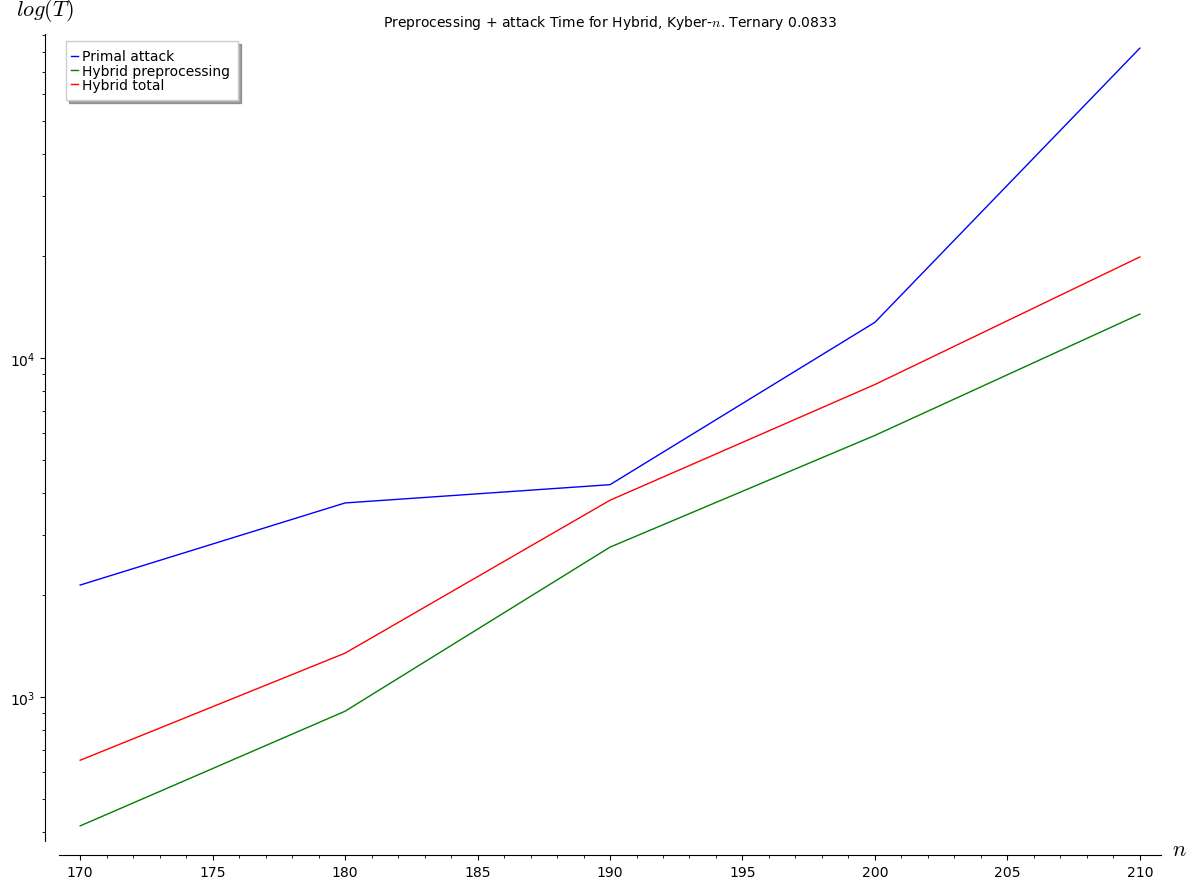

In [25]:
L = {}
available_ns = []
"""
The tha files now have a new naming convention.
"""

data = []
path = "./lwe_instances/reduced_lattices/"
pattern = re.compile(r'''
    ^tph_                          
    (?P<n>\d+)_                    
    (?P<dist>[^_]+)_               
    (?P<dist_param>[+-]?\d+\.\d{4})_  
    (?P<kappa>\d+)_                
    (?P<beta_bkz>\d+)_             
    (?P<sieve_dim_max>\d+)         
    \.pkl$                         
''', re.VERBOSE)
regex = re.compile(pattern)

lol=0
max_n = 0
for path, directories, files in os.walk(path):
    lol+=1
    for candidate in files:
        match = regex.match(candidate)
        print(f"aaaa: {candidate} | {match}")
        if match and sec_type in candidate and f"{sec_param:0.4f}" in candidate:
            gd = match.groupdict()
            n             = int(gd['n'])
            dist          = gd['dist']
            dist_param    = float(gd['dist_param'])
            kappa         = int(gd['kappa'])
            sieve_dim_max = int(gd['sieve_dim_max'])
            beta_bkz      = int(gd['beta_bkz'])
            
            available_ns.append(n)
            with open(path+candidate,"rb") as file:
                L.update( pickle.load(file) )
            

wtimes = {}
succs = {}
for n in available_ns:
    wtimes[n] = []
    if not n in succs:
        succs[n] = [0,0]
    
NRAND_FACTOR = 10.
for key in L:
    n, _, n_slicer_coord, n_guess_coord, _ = key
    print(n,n_guess_coord,n_slicer_coord)
    print( n_guess_coord == hparams[n][0] )
    if n_guess_coord == hparams[n][0]:
        print( n,n_guess_coord, hparams[n][0] )
        nrand_, _ = batchCVPP_cost(n_slicer_coord,100,L[key]["g6k_len"] **(1./n_slicer_coord),1)
        nrand = ceil(NRAND_FACTOR*(1./nrand_)**n_slicer_coord)
        utar_per_batch = ceil( L[key]["g6k_len"] / nrand ) #how many unique targets in batch
    
        curtime = abs( L[key]["wrong_guess_time_alg2"] ) + abs( L[key]["wrong_guess_time_alg3"] )
        overhead_tsieve = L[key]["overhead_tsieve"]
        batnum = L[key]["key_num"]/utar_per_batch
        curtime *= batnum  #time * how many batches needed
        wtimes[n].append( curtime + overhead_tsieve )
        succs[n][0]+=1
        succs[n][1]+=L[key]['succ']

for n in available_ns:
    wtimes[n] = np.mean(wtimes[n])
    try:
        # print(n)
        cur_succ_rate = float(succs[n][1] / succs[n][0])
    except TypeError:
        cur_succ_rate = succs[n]
    succs[n] = cur_succ_rate if cur_succ_rate>0 else 1/100.

ltot_hyb_att = {}
for key in wtimes.keys():
    walltime = wtimes[key]
    ltot_hyb_att[key] = l1[key] + ( 2*walltime ) / succs[key]  #success rate is 1/2 * slicer's proba

P += list_plot_semilogy(ltot_hyb_att, plotjoined=True, base=10, axes_labels=["$n$", "$log(T)$"], color="red", legend_label="Hybrid total")
plotfilename = f"time_{dist}_{dist_param:0.4f}_{available_ns}.png"
P.show( title=f'Preprocessing + attack Time for Hybrid, Kyber-$n$. Ternary {dist_param}', figsize=12 )